In [3]:
# 1. how does the Adam optimazation function work?
# The adam optimization function works by keeping track of the first and second moments of the gradients and then keeps track of their averages as well as their squares for each parameter.
# It then uses these to adjust how much each parameter is updated to help optimize towards a minimum



In [4]:
import pandas as pd
import torch

diabetes_df = pd.read_csv("diabetes.csv")

In [5]:
from sklearn.model_selection import train_test_split
X = diabetes_df.drop('Outcome', axis=1).values
y = diabetes_df['Outcome'].values

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.3,
                                                    random_state=50,
                                                    stratify=y)

In [6]:
import torch.nn as nn
import torch.nn.functional as F # function has activation functions

# create tensors from the data
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [7]:
class ANN_Model(nn.Module):
    def __init__(self, input_features=8,
                hidden1=20, hidden2=20,
                out_features=2):
        super().__init__()
        """
        super is a computed indirect reference
        which means that it isolates changes and
        makes sure the children in the layer of
        multiple inheritance are calling the
        right parents
        """
        self.layer_1_connection = nn.Linear(input_features, hidden1)
        self.layer_2_connection = nn.Linear(hidden1, hidden2)
        self.out = nn.Linear(hidden2, out_features)
    
    def forward(self, x):
        """
        apply activation function
        """
        x = F.relu(self.layer_1_connection(x))
        x = F.relu(self.layer_2_connection(x))
        x = self.out(x)
        return x

In [8]:
torch.manual_seed(50)

#create an instance of the model
ann=ANN_Model()

In [13]:
# loss function 
loss_function = nn.CrossEntropyLoss()

# optimizer with NAdam instead of Adam
optimizer = torch.optim.NAdam(ann.parameters(), lr = 0.01)

In [15]:
# run model through various epochs/iterations
final_loss = []
n_epochs = 500
for epoch in range(n_epochs):
    y_pred = ann.forward(X_train)
    loss = loss_function(y_pred, y_train)
    final_loss.append(loss)

    if epoch % 10 == 1:
        print(f'Epoch number: {epoch} with loss {loss}')

    optimizer.zero_grad() # zeros the gradient before running backward propagation
    loss.backward() # working to minimize the loss function using backward propagation
    optimizer.step() # perform one optimization step each function

Epoch number: 1 with loss 2.68853759765625
Epoch number: 11 with loss 0.5251263380050659
Epoch number: 21 with loss 0.4562934637069702
Epoch number: 31 with loss 0.43047428131103516
Epoch number: 41 with loss 0.41148069500923157
Epoch number: 51 with loss 0.3853697180747986
Epoch number: 61 with loss 0.3800276517868042
Epoch number: 71 with loss 0.43201208114624023
Epoch number: 81 with loss 0.39198821783065796
Epoch number: 91 with loss 0.41901451349258423
Epoch number: 101 with loss 0.3730485141277313
Epoch number: 111 with loss 0.45782747864723206
Epoch number: 121 with loss 0.3519366979598999
Epoch number: 131 with loss 0.46691152453422546
Epoch number: 141 with loss 0.3810676634311676
Epoch number: 151 with loss 0.4159644842147827
Epoch number: 161 with loss 0.3665741980075836
Epoch number: 171 with loss 0.412465900182724
Epoch number: 181 with loss 0.3625354468822479
Epoch number: 191 with loss 0.36065760254859924
Epoch number: 201 with loss 0.3795662522315979
Epoch number: 211 w

In [20]:
y_pred = []
with torch.no_grad(): # this helps decrease memory consumption
    for i, data in enumerate(X_test):
        prediction = ann(data)
        y_pred.append(prediction.argmax().item())

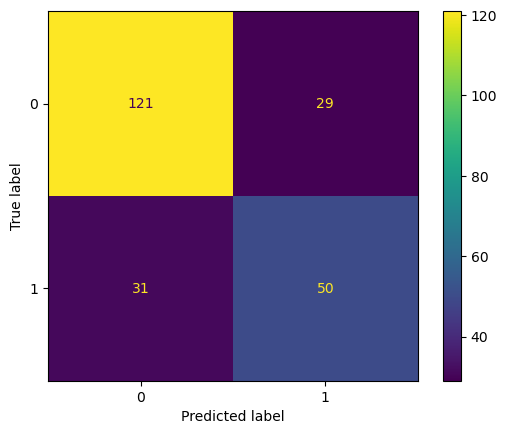

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test.numpy(), y_pred)

In [ ]:
# recall = TP / (TP + FN)
50/(50+31)
# the NAdam optimizer yielded a better recall than the adam optimizer but it still is not that good a recall.

0.6172839506172839